In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
import matplotlib as mpl
pd.options.mode.chained_assignment = None


eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_p2d/"
res_DIR = "../data/results_p2d/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [2]:
cell = 1

In [3]:
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)

In [4]:
sno = 0

In [5]:
dfn = pybamm.lithium_ion.DFN(
    {
        "SEI": "ec reaction limited",
        "loss of active material": "stress-driven",
        "lithium plating": "irreversible",
        "stress-induced diffusion": "false",
    }
)
param=dfn.param
parameter_values = get_parameter_values()   
# sim_des = sim_des+'_cv'
cell_no,dfe,dfe_0,dfo_0,N,N_0 = load_data(cell,eSOH_DIR,oCV_DIR)
Ns = np.insert(N_0[1:]-1,0,0)
eps_n_data,eps_p_data,c_rate_c,c_rate_d,dis_set,Temp,SOC_0 = init_exp(cell_no,dfe,dfn,parameter_values)
pybamm.set_logging_level("WARNING")
par_val = {}
# Room temp
par_val[0] = [4.0312e-08,1.8157e-07,1.0776,2.3586e-09,-4.9170e-09,-1.4406e-09,4.60788219e-16,4.56607447e-19]
parameter_values = get_parameter_values()
parameter_values.update(
    {   
        "Positive electrode diffusion coefficient activation energy [J.mol-1]": 0,
        "Negative electrode diffusion coefficient activation energy [J.mol-1]": 0,
        "Positive electrode reference exchange-current density activation energy [J.mol-1]": 0,
        "Negative electrode reference exchange-current density activation energy [J.mol-1]": 0,
        "Positive electrode diffusion coefficient [m2.s-1]": 8e-15,
        "Negative electrode diffusion coefficient [m2.s-1]": 8e-14,
        "Positive electrode reference exchange-current density [A.m-2(m3.mol)1.5]": 3.377e-06,
        "Negative electrode reference exchange-current density [A.m-2(m3.mol)1.5]":	3.183e-06,
        "Negative electrode active material volume fraction": eps_n_data,
        "Positive electrode active material volume fraction": eps_p_data,
        "Initial temperature [K]": 273.15+Temp,
        "Ambient temperature [K]": 273.15+Temp,
        "Positive electrode LAM constant proportional term [s-1]": par_val[sno][0],
        "Negative electrode LAM constant proportional term [s-1]": par_val[sno][1],
        "Positive electrode LAM constant proportional term 2 [s-1]": par_val[sno][5],
        "Negative electrode LAM constant proportional term 2 [s-1]": par_val[sno][4],
        "Positive electrode LAM constant exponential term": par_val[sno][2],
        "Negative electrode LAM constant exponential term": par_val[sno][2],
        "SEI kinetic rate constant [m.s-1]":  par_val[sno][6], #1.08494281e-16 , 
        "EC diffusivity [m2.s-1]": par_val[sno][7],#8.30909086e-19,
        "SEI growth activation energy [J.mol-1]": 1.87422275e+04,#1.58777981e+04,
        "Lithium plating kinetic rate constant [m.s-1]": par_val[sno][3],
        "Initial inner SEI thickness [m]": 0e-09,
        "Initial outer SEI thickness [m]": 5e-09,
        "Li plating resistivity [Ohm.m]": 30000,
        "SEI resistivity [Ohm.m]": 30000.0,
        "Negative electrode partial molar volume [m3.mol-1]": 7e-06,
        "Negative electrode LAM min stress [Pa]": 0,
        "Negative electrode LAM max stress [Pa]": 0,
        "Positive electrode LAM min stress [Pa]": 0,
        "Positive electrode LAM max stress [Pa]": 0,
        # "Negative electrode diffusion coefficient [m2.s-1]": 8e-14,
        # "Positive electrode diffusion coefficient [m2.s-1]": 8e-15,
        # "Negative electrode critical stress [Pa]": 20e+06,
        # "Positive electrode critical stress [Pa]": 40e+06,
    },
    check_already_exists=False,
)
if cell == 13 or cell == 16:
    parameter_values.update(
        {
            "Negative electrode partial molar volume [m3.mol-1]":	0.747*7e-06,
        },
        check_already_exists=False,
    )

experiment = pybamm.Experiment(
    [
        ("Charge at "+c_rate_c+" until 4.2V", 
        "Hold at 4.2V until C/100",
        "Discharge at "+c_rate_d+dis_set,)
    ],
    termination="50% capacity",
)
SOC_0 = 0
sols = []
parameter_values.update(
    {
        "Negative electrode LAM min stress [Pa]": 0,
        "Negative electrode LAM max stress [Pa]": 0,
        "Positive electrode LAM min stress [Pa]": 0,
        "Positive electrode LAM max stress [Pa]": 0,

    },
    check_already_exists=False,
)

In [6]:
sim_long = pybamm.Simulation(dfn, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol1 = sim_long.solve(initial_soc=SOC_0)
sigma_ts_n = sol1["X-averaged negative particle surface tangential stress [Pa]"].entries
sigma_rs_n = sol1["X-averaged negative particle surface radial stress [Pa]"].entries
sigma_hs_n = (sigma_rs_n+2*sigma_ts_n)/2
sigma_ts_p = sol1["X-averaged positive particle surface tangential stress [Pa]"].entries
sigma_rs_p = sol1["X-averaged positive particle surface radial stress [Pa]"].entries
sigma_hs_p = (sigma_rs_p+2*sigma_ts_p)/2

The linesearch algorithm failed with too small a step.
2025-06-27 13:07:03.188 - [ERROR] callbacks.on_experiment_error(226): Simulation error: .../casadi/interfaces/sundials/idas_interface.cpp:591: IDACalcIC returned "IDA_LINESEARCH_FAIL". Consult IDAS documentation.


In [ ]:
pybamm.solver

In [7]:
sol1

In [8]:
parameter_values.update(
    {
        "Negative electrode LAM min stress [Pa]": min(sigma_hs_n),
        "Negative electrode LAM max stress [Pa]": max(sigma_hs_n),
        "Positive electrode LAM min stress [Pa]": min(sigma_hs_p),
        "Positive electrode LAM max stress [Pa]": max(sigma_hs_p),

    },
    check_already_exists=False,
)
sim_long = pybamm.Simulation(dfn, experiment=experiment, parameter_values=parameter_values, 
                            solver=pybamm.CasadiSolver("safe"))
sol2 = sim_long.solve(initial_soc=SOC_0)
dfn.set_initial_conditions_from(sol2, inplace=True)
sols.append(sol2)

The linesearch algorithm failed with too small a step.
2025-06-27 13:07:31.970 - [ERROR] callbacks.on_experiment_error(226): Simulation error: .../casadi/interfaces/sundials/idas_interface.cpp:591: IDACalcIC returned "IDA_LINESEARCH_FAIL". Consult IDAS documentation.


In [9]:
N = dfe.N.iloc[-1]
for i in tqdm(range(N-1)):
    sigma_ts_n = sol2["X-averaged negative particle surface tangential stress [Pa]"].entries
    sigma_rs_n = sol2["X-averaged negative particle surface radial stress [Pa]"].entries
    sigma_hs_n = (sigma_rs_n+2*sigma_ts_n)/2
    sigma_ts_p = sol2["X-averaged positive particle surface tangential stress [Pa]"].entries
    sigma_rs_p = sol2["X-averaged positive particle surface radial stress [Pa]"].entries
    sigma_hs_p = (sigma_rs_p+2*sigma_ts_p)/2
    parameter_values.update(
        {
            "Negative electrode LAM min stress [Pa]": min(sigma_hs_n),
            "Negative electrode LAM max stress [Pa]": max(sigma_hs_n),
            "Positive electrode LAM min stress [Pa]": min(sigma_hs_p),
            "Positive electrode LAM max stress [Pa]": max(sigma_hs_p),

        },
        check_already_exists=False,
    )
    sim_long = pybamm.Simulation(dfn, experiment=experiment, parameter_values=parameter_values, 
                                solver=pybamm.CasadiSolver("safe"))
    sol2 = sim_long.solve()
    dfn.set_initial_conditions_from(sol2, inplace=True)
    # if (i+1)%10 == 0:
    sols.append(sol2)

  0%|          | 0/338 [00:00<?, ?it/s]The linesearch algorithm failed with too small a step.
2025-06-27 13:07:47.694 - [ERROR] callbacks.on_experiment_error(226): Simulation error: .../casadi/interfaces/sundials/idas_interface.cpp:591: IDACalcIC returned "IDA_LINESEARCH_FAIL". Consult IDAS documentation.
  0%|          | 1/338 [00:15<1:27:42, 15.62s/it]The linesearch algorithm failed with too small a step.
2025-06-27 13:08:03.106 - [ERROR] callbacks.on_experiment_error(226): Simulation error: .../casadi/interfaces/sundials/idas_interface.cpp:591: IDACalcIC returned "IDA_LINESEARCH_FAIL". Consult IDAS documentation.
  1%|          | 2/338 [00:31<1:26:56, 15.52s/it]The linesearch algorithm failed with too small a step.
2025-06-27 13:08:18.678 - [ERROR] callbacks.on_experiment_error(226): Simulation error: .../casadi/interfaces/sundials/idas_interface.cpp:591: IDACalcIC returned "IDA_LINESEARCH_FAIL". Consult IDAS documentation.
  1%|          | 3/338 [00:46<1:26:41, 15.53s/it]The linese

SolverError: All steps in the cycle ('Charge at C/5 until 4.2V', 'Hold at 4.2V until C/100', 'Discharge at C/5 until 3V') are infeasible due to exceeded bounds at initial conditions.

In [10]:
def get_c(sols):
    Cn = []
    for i in range(len(sols)):
        sol_long = sols[i]
        Cn1 = sol_long.all_summary_variables
        Cn2 = Cn1[0]['C']
        Cn.append(Cn2)
    Cn = np.array(Cn)
    return Cn

In [26]:
def get_esoh(sols):
    Cn,Cp,x0,x100,y0,y100 = [],[],[],[],[],[]
    for i in range(len(sols)):
        sol_long = sols[i]
        C1 = sol_long.all_summary_variables
        C2 = C1[0]['C_n']
        Cn.append(C2)
        C2 = C1[0]['C_p']
        Cp.append(C2)
        C2 = C1[0]['x_0']
        x0.append(C2)
        C2 = C1[0]['x_100']
        x100.append(C2)
        C2 = C1[0]['y_0']
        y0.append(C2)
        C2 = C1[0]['y_100']
        y100.append(C2)
    Cn = np.array(Cn)
    Cp = np.array(Cp)
    x0 = np.array(x0)
    x100 = np.array(x100)
    y0 = np.array(y0)
    y100 = np.array(y100)
    return Cn,Cp,x0,x100,y0,y100

In [34]:
pybamm.version

<module 'pybamm.version' from 'c:\\users\\spannala\\pybamm\\pybamm\\version.py'>

In [11]:
get_c(sols)

array([4.86237046, 4.86237046, 4.86237046, 4.86237046, 4.86237046,
       4.86237046, 4.86237046, 4.86237046, 4.86237046, 4.86237046,
       4.86237046, 4.86237046, 4.86237046])

In [27]:
Cn,Cp,x0,x100,y0,y100 = get_esoh(sols)

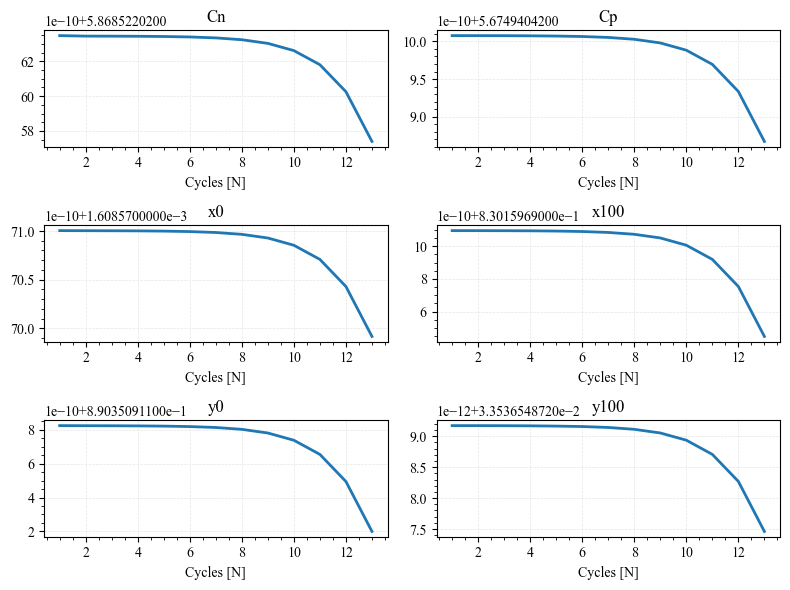

In [31]:
fig,ax = plt.subplots(3,2,figsize=(8,6))
ax1 = ax.flat[0]
ax1.plot(range(1,len(Cn)+1),Cn)
ax1.set_title("Cn")
ax1.set_xlabel("Cycles [N]")
ax2 = ax.flat[1]
ax2.plot(range(1,len(Cp)+1),Cp)
ax2.set_title("Cp")
ax2.set_xlabel("Cycles [N]")
ax3 = ax.flat[2]
ax3.plot(range(1,len(x0)+1),x0)
ax3.set_title("x0")
ax3.set_xlabel("Cycles [N]")
ax4 = ax.flat[3]
ax4.plot(range(1,len(x100)+1),x100)
ax4.set_title("x100")
ax4.set_xlabel("Cycles [N]")
ax5 = ax.flat[4]
ax5.plot(range(1,len(y0)+1),y0)
ax5.set_title("y0")
ax5.set_xlabel("Cycles [N]")
ax6 = ax.flat[5]
ax6.plot(range(1,len(y100)+1),y100)
ax6.set_title("y100")
ax6.set_xlabel("Cycles [N]")
fig.tight_layout()
fig.savefig(fig_DIR + "DFN_eSOH_1.png")